# ¿Por qué la evolución no ha borrado los genes que nos enferman?

Si un gen te sube el riesgo de una enfermedad, deberías tener menos hijos y ese gen debería desaparecer. Pero no desaparece. Miles de variantes de riesgo siguen ahí, generación tras generación.

:::{image} figuras/pixabot.png
:alt: Pixabot mascot
:width: 80px
:align: center
:figclass: pixabot-mascot
:::

**Paper:** Brigos-Barril et al. (2026), *Nature Ecology & Evolution* · [DOI](https://doi.org/10.1038/s41559-026-03140-z)

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-07-21-genetic-tradeoffs-fertility-longevity/notebook.ipynb)

**Video:** [Pendiente]

El equipo cruzó datos genéticos de **62 enfermedades** con datos de longevidad y de número de hijos, usando dos biobancos enormes (UK Biobank y FinRegistry). La idea que ponen a prueba viene de la teoría de historia de vida: una variante dañina puede sobrevivir si, además de enfermar, te ayuda a tener más descendencia. Le llaman **pleiotropía antagónica** — un mismo gen con un efecto bueno y uno malo tirando en direcciones opuestas.

La pregunta concreta: ¿los alelos de riesgo persisten porque, en promedio, suben la fertilidad aunque cuesten salud y años de vida?

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
N_DISEASES = 62              # enfermedades analizadas
UMBRAL_ONSET = 40           # edad (años) que separa aparición temprana / tardía
COLOR_DATOS = '#2563EB'      # azul CaM
COLOR_ALERTA = '#DC2626'     # rojo
COLOR_SECUNDARIO = '#059669' # emerald
COLOR_REFERENCIA = '#D97706' # amber
COLOR_GRIS = '#BBBBBB'
FUENTE = 'Fuente: Brigos-Barril et al. (2026), Nature Ecol. Evol. | Datos: Zenodo 20439635'

import os, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Estilo CaM (local -> fallback GitHub raw)
BASE = 'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main'
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(f'{BASE}/cam.mplstyle', style_file)
plt.style.use(style_file)

DATA = 'datos'
tradeoff = pd.read_csv(f'{DATA}/tradeoff_loci.csv')          # 285 loci pleiotrópicos
childless = pd.read_csv(f'{DATA}/childlessness_by_onset.csv') # 62 enfermedades
sds = pd.read_csv(f'{DATA}/seleccion_sds.csv')                # 293 alelos, señal de selección
mr = pd.read_csv(f'{DATA}/mr_results.csv')                    # randomización mendeliana

print('Loci pleiotrópicos (fertilidad + riesgo):', len(tradeoff))
print('Enfermedades con datos de hijos          :', len(childless))
print('Alelos con señal de selección (SDS)      :', len(sds))
print('Pruebas de randomización mendeliana      :', len(mr))

Loci pleiotrópicos (fertilidad + riesgo): 285
Enfermedades con datos de hijos          : 62
Alelos con señal de selección (SDS)      : 293
Pruebas de randomización mendeliana      : 88


## El canje evolutivo (trade-off), en una sola gráfica

Aquí está.

Spearman rho = -0.362 (p = 2.9e-10)
Pearson  r   = -0.351 (p = 1.1e-09)  <- valor del paper


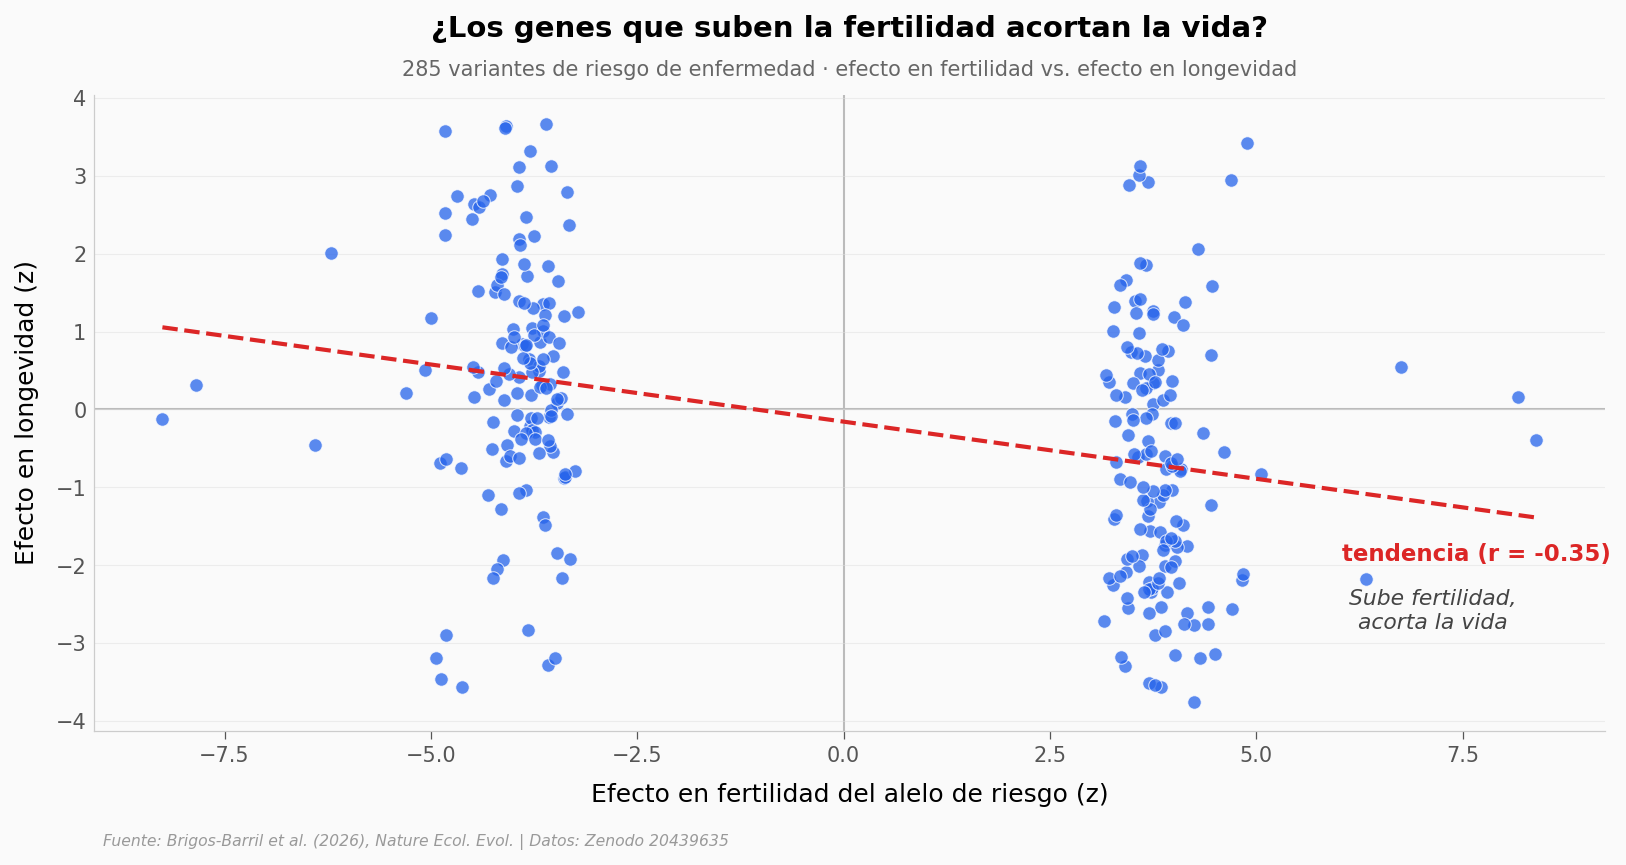

In [2]:
x = tradeoff['fert_z_riskallele']   # efecto del alelo de riesgo sobre la fertilidad
y = tradeoff['lifespan_z_riskallele'] # efecto del mismo alelo sobre la longevidad

# Correlación: Spearman por defecto (datos no normales) + Pearson (lo que reporta el paper)
rho, p_rho = stats.spearmanr(x, y)
r_pearson, p_pearson = stats.pearsonr(x, y)
print(f'Spearman rho = {rho:.3f} (p = {p_rho:.1e})')
print(f'Pearson  r   = {r_pearson:.3f} (p = {p_pearson:.1e})  <- valor del paper')

fig, ax = plt.subplots(figsize=(13, 5.5))
ax.axhline(0, color=COLOR_GRIS, linewidth=1, zorder=1)
ax.axvline(0, color=COLOR_GRIS, linewidth=1, zorder=1)
ax.scatter(x, y, color=COLOR_DATOS, s=42, alpha=0.75,
           edgecolors='white', linewidths=0.5, zorder=5)

# Recta de tendencia (mínimos cuadrados) para hacer visible la pendiente negativa
b, a = np.polyfit(x, y, 1)
xs = np.linspace(x.min(), x.max(), 100)
ax.plot(xs, a + b*xs, color=COLOR_ALERTA, linewidth=2, linestyle='--', zorder=6)
ax.text(x.max()*0.72, a + b*x.max()*0.72 - 0.9,
        f'tendencia (r = {r_pearson:.2f})', color=COLOR_ALERTA,
        fontsize=11, fontweight='bold')

ax.annotate('Sube fertilidad,\nacorta la vida',
            xy=(x.max()*0.85, y.min()*0.75), fontsize=10.5,
            color='#444444', ha='center', style='italic')

ax.set_title('¿Los genes que suben la fertilidad acortan la vida?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, '285 variantes de riesgo de enfermedad · efecto en fertilidad vs. efecto en longevidad',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlabel('Efecto en fertilidad del alelo de riesgo (z)')
ax.set_ylabel('Efecto en longevidad (z)')
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/hero_tradeoff.png', dpi=200, bbox_inches='tight')
plt.show()

La nube se inclina: cuanto más sube un alelo la fertilidad, más tiende a recortar la longevidad (r = −0,35, Pearson; ρ = −0,36, Spearman; n = 285). No es una relación fuerte —la mayoría de la dispersión queda sin explicar— pero es clara y muy significativa (p < 0,0001), y apunta en una sola dirección.

Un matiz honesto: si solo miras el efecto medio sobre la longevidad de estos alelos de riesgo, la caída es leve (z medio = −0,16) y **no** alcanza significancia por sí sola (p = 0,11). El hallazgo no es "estos alelos acortan la vida", es el **trade-off**: los que más ayudan a reproducirse son justo los que más cuestan en años. Correlación, no causa — es un estudio observacional.

## El giro: ¿tener la enfermedad significa tener menos hijos?

Uno esperaría que estar enfermo reduzca el número de hijos. Los datos dicen algo más raro.

Correlación edad de aparición vs exceso sin hijos: r = -0.591 / rho = -0.544 (n = 62)
Aparición temprana (<40a, n=15): exceso medio = +11.82 pp
Aparición tardía  (>=40a, n=47): exceso medio = -2.04 pp
Enfermedades donde los afectados tienen MÁS hijos: 44 de 62


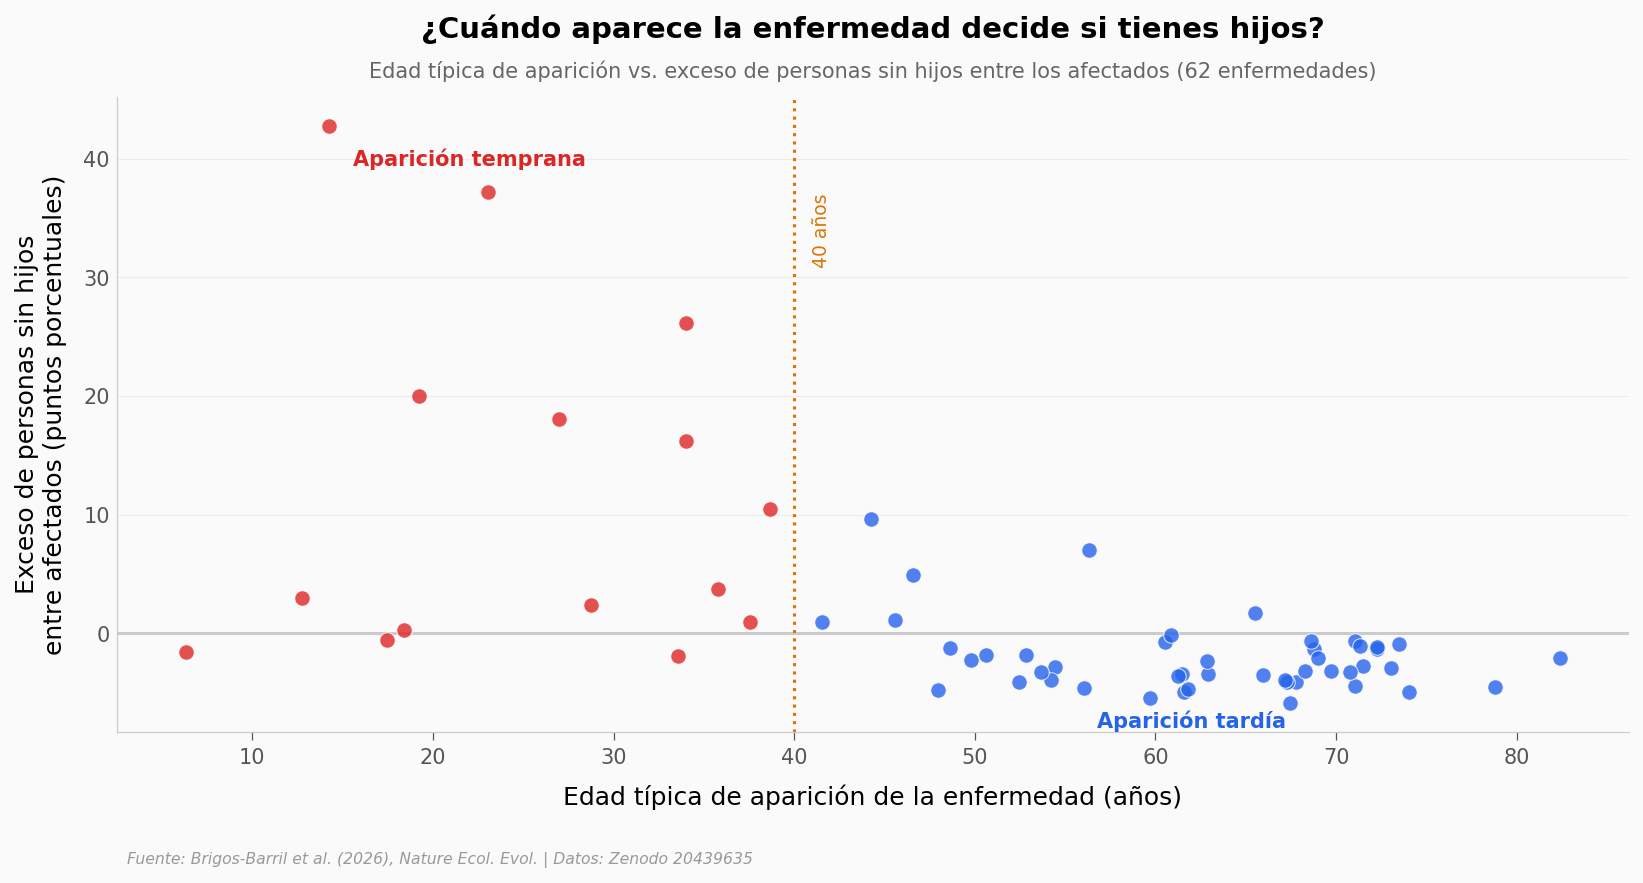

In [3]:
# Exceso de personas sin hijos entre afectados vs no afectados (puntos porcentuales)
rho_c, p_c = stats.spearmanr(childless['ADO_50'], childless['excess_childless_pp'])
r_c, _ = stats.pearsonr(childless['ADO_50'], childless['excess_childless_pp'])
early = childless[childless['onset_group'].str.contains('early')]
late = childless[childless['onset_group'].str.contains('late')]
print(f'Correlación edad de aparición vs exceso sin hijos: r = {r_c:.3f} / rho = {rho_c:.3f} (n = {len(childless)})')
print(f'Aparición temprana (<{UMBRAL_ONSET}a, n={len(early)}): exceso medio = {early["excess_childless_pp"].mean():+.2f} pp')
print(f'Aparición tardía  (>={UMBRAL_ONSET}a, n={len(late)}): exceso medio = {late["excess_childless_pp"].mean():+.2f} pp')
print(f'Enfermedades donde los afectados tienen MÁS hijos: {(childless["excess_childless_pp"]<0).sum()} de {len(childless)}')

fig, ax = plt.subplots(figsize=(13, 5.5))
ax.axhline(0, color=COLOR_GRIS, linewidth=1.2, zorder=1)
ax.axvline(UMBRAL_ONSET, color=COLOR_REFERENCIA, linewidth=1.5, linestyle=':', zorder=2)
ax.scatter(early['ADO_50'], early['excess_childless_pp'], color=COLOR_ALERTA, s=55,
           alpha=0.8, edgecolors='white', linewidths=0.5, zorder=5)
ax.scatter(late['ADO_50'], late['excess_childless_pp'], color=COLOR_DATOS, s=55,
           alpha=0.8, edgecolors='white', linewidths=0.5, zorder=5)
ax.text(22, early['excess_childless_pp'].max()*0.92, 'Aparición temprana',
        color=COLOR_ALERTA, fontsize=10, fontweight='bold', ha='center')
ax.text(62, -8, 'Aparición tardía', color=COLOR_DATOS, fontsize=10, fontweight='bold', ha='center')
ax.text(UMBRAL_ONSET+1, ax.get_ylim()[1]*0.82, f'{UMBRAL_ONSET} años',
        color=COLOR_REFERENCIA, fontsize=9, rotation=90, va='top')

ax.set_title('¿Cuándo aparece la enfermedad decide si tienes hijos?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Edad típica de aparición vs. exceso de personas sin hijos entre los afectados (62 enfermedades)',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlabel('Edad típica de aparición de la enfermedad (años)')
ax.set_ylabel('Exceso de personas sin hijos\nentre afectados (puntos porcentuales)')
fig.text(0.13, -0.05, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/childlessness_onset.png', dpi=200, bbox_inches='tight')
plt.show()

## ¿Correlación o causa? La prueba mendeliana

Hasta aquí todo son asociaciones. Para acercarse a la causalidad, el equipo usó **randomización mendeliana**: como los genes se reparten al azar en la concepción, sirven de "experimento natural" para preguntar si la predisposición a una enfermedad *causa* menos longevidad o menos fertilidad.

Enfermedades probadas sobre longevidad y fertilidad: 41
Longevidad: 22 de 43 efectos causales significativos
Fertilidad: 12 de 45 efectos causales significativos


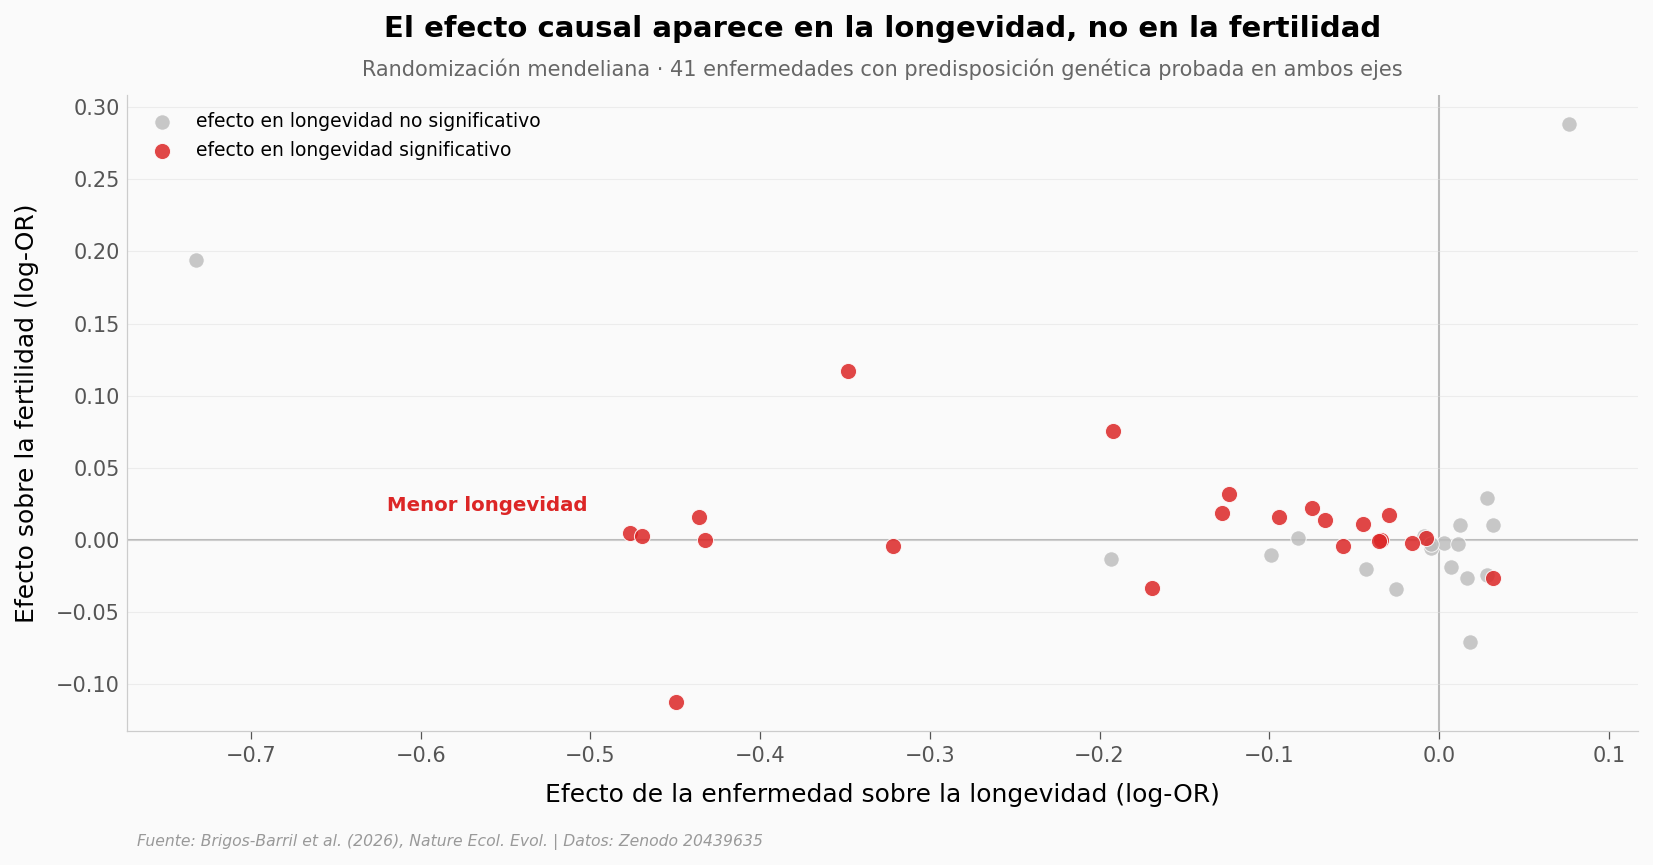

In [4]:
lon = mr[mr['outcome']=='longevity'][['Acronym','Estimate','Significance']].rename(
    columns={'Estimate':'est_lon','Significance':'sig_lon'})
fer = mr[mr['outcome']=='fertility'][['Acronym','Estimate','Significance']].rename(
    columns={'Estimate':'est_fer','Significance':'sig_fer'})
paired = lon.merge(fer, on='Acronym', how='inner')  # enfermedades probadas en ambos
print('Enfermedades probadas sobre longevidad y fertilidad:', len(paired))

n_lon = (mr['outcome']=='longevity').sum(); n_lon_sig = ((mr['outcome']=='longevity') & (mr['Significance']=='S')).sum()
n_fer = (mr['outcome']=='fertility').sum(); n_fer_sig = ((mr['outcome']=='fertility') & (mr['Significance']=='S')).sum()
print(f'Longevidad: {n_lon_sig} de {n_lon} efectos causales significativos')
print(f'Fertilidad: {n_fer_sig} de {n_fer} efectos causales significativos')

fig, ax = plt.subplots(figsize=(13, 5.5))
ax.axhline(0, color=COLOR_GRIS, linewidth=1, zorder=1)
ax.axvline(0, color=COLOR_GRIS, linewidth=1, zorder=1)
sig = paired['sig_lon']=='S'
ax.scatter(paired.loc[~sig,'est_lon'], paired.loc[~sig,'est_fer'], color=COLOR_GRIS, s=55,
           alpha=0.8, edgecolors='white', linewidths=0.5, zorder=4, label='efecto en longevidad no significativo')
ax.scatter(paired.loc[sig,'est_lon'], paired.loc[sig,'est_fer'], color=COLOR_ALERTA, s=60,
           alpha=0.85, edgecolors='white', linewidths=0.5, zorder=5, label='efecto en longevidad significativo')
ax.legend(fontsize=9, loc='upper left', framealpha=0.9)
ax.text(-0.62, 0.02, 'Menor longevidad', color=COLOR_ALERTA, fontsize=9.5, fontweight='bold')

ax.set_title('El efecto causal aparece en la longevidad, no en la fertilidad',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, f'Randomización mendeliana · {len(paired)} enfermedades con predisposición genética probada en ambos ejes',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlabel('Efecto de la enfermedad sobre la longevidad (log-OR)')
ax.set_ylabel('Efecto sobre la fertilidad (log-OR)')
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/mr_asymmetry.png', dpi=200, bbox_inches='tight')
plt.show()

## ¿Y la selección natural sigue moviendo estos alelos?

Si el trade-off es real, la selección reciente debería haber favorecido las variantes que suben la fertilidad. Hay una firma en el genoma para medir eso: el **SDS** (singleton density score), que capta selección de los últimos ~2.000–3.000 años. Un SDS positivo = el alelo pro-fertilidad se ha vuelto más común.

SDS medio = 0.277 | mediana = 0.178 | 56.3% positivos (n = 293)
t-test vs 0: p = 6.9e-05  |  Wilcoxon: p = 5.9e-04


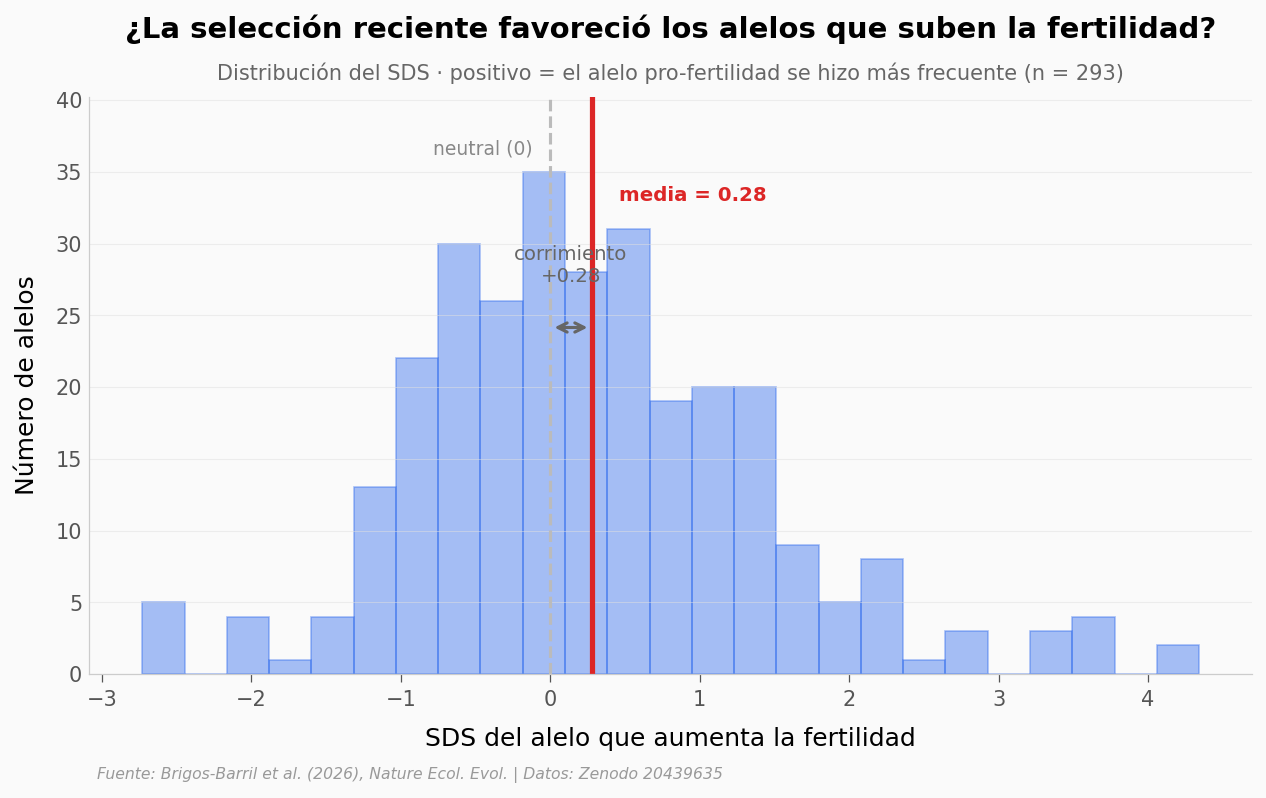

In [5]:
vals = sds['sds_fertility_increasing']
media = vals.mean(); mediana = vals.median()
pct_pos = (vals > 0).mean()*100
t_stat, p_t = stats.ttest_1samp(vals, 0)
w_stat, p_w = stats.wilcoxon(vals)
print(f'SDS medio = {media:.3f} | mediana = {mediana:.3f} | {pct_pos:.1f}% positivos (n = {len(vals)})')
print(f't-test vs 0: p = {p_t:.1e}  |  Wilcoxon: p = {p_w:.1e}')

fig, ax = plt.subplots(figsize=(10, 5))
n, bins, patches = ax.hist(vals, bins=25, color=COLOR_DATOS, alpha=0.4,
                           edgecolor=COLOR_DATOS, linewidth=0.8)
y_max = n.max()*1.15
ax.set_ylim(0, y_max)
ax.axvline(0, color=COLOR_GRIS, linewidth=1.5, linestyle='--')
ax.axvline(media, color=COLOR_ALERTA, linewidth=2.5)
ax.annotate('', xy=(media, y_max*0.6), xytext=(0, y_max*0.6),
            arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.5))
ax.text(media/2, y_max*0.68, f'corrimiento\n+{media:.2f}', ha='center',
        fontsize=9.5, color='#666666')
ax.text(-0.12, y_max*0.9, 'neutral (0)', color='#888888', fontsize=9, ha='right')
ax.text(media+0.18, y_max*0.82, f'media = {media:.2f}', color=COLOR_ALERTA,
        fontsize=9.5, fontweight='bold', ha='left')

ax.set_title('¿La selección reciente favoreció los alelos que suben la fertilidad?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Distribución del SDS · positivo = el alelo pro-fertilidad se hizo más frecuente (n = 293)',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlabel('SDS del alelo que aumenta la fertilidad')
ax.set_ylabel('Número de alelos')
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/sds_seleccion.png', dpi=200, bbox_inches='tight')
plt.show()

### Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| Los alelos que suben la fertilidad tienden a acortar la longevidad | ✅ | r = −0,35 (Pearson) / ρ = −0,36 (Spearman), n = 285, p < 0,0001. Correlación moderada; el 88% de la dispersión queda sin explicar. Observacional: asociación, no causa. |
| Los alelos de riesgo, en promedio, acortan la vida | ⚠️ | El corrimiento medio es leve (z = −0,16) y **no** significativo en este subconjunto (p = 0,11). El paper apoya el efecto medio con el análisis genómico completo + MR, no con estos 285 loci. |
| La predisposición a la enfermedad reduce causalmente la longevidad | ✅ | Randomización mendeliana: 22 de 43 enfermedades con efecto significativo; 30 de 43 apuntan a menor longevidad. Único lugar donde el diseño permite hablar de causa. |
| …y también reduce la fertilidad | ❌ | Solo 12 de 45 significativas; el paper lo describe como *sin evidencia robusta*. |
| Estar enfermo casi siempre significa tener menos hijos | ❌ | Al revés para la mayoría: en 44 de 62 enfermedades los afectados tienen **más** hijos que los no afectados. |
| El giro ocurre en las enfermedades de aparición temprana | ✅ | Aparición <40 años: +11,8 pp de exceso sin hijos (n = 15); aparición ≥40: −2,0 pp (n = 47); la brecha entre grupos es grande (Cohen's d = 1,85; Mann-Whitney p < 0,0001). Correlación edad↔coste: r = −0,59. |
| Estos alelos parecen favorecidos por la selección reciente | ✅ | SDS medio +0,28, 56% positivos, p = 7×10⁻⁵ (t) / 6×10⁻⁴ (Wilcoxon), n = 293. |

> **Limitaciones:** (1) Estudio observacional; salvo la randomización mendeliana sobre longevidad, todo es asociación. (2) El SDS capta selección de los últimos ~2.000–3.000 años; los "50.000 años" del abstract vienen de otras firmas (iHS/nSL) que no están en este archivo — no atribuir la señal SDS a esa ventana. (3) Datos de ascendencia mayoritariamente europea (UK Biobank, FinRegistry): no generaliza sin más a otras poblaciones. (4) La correlación del trade-off es moderada (r = −0,35): describe una tendencia poblacional, no el destino de ningún gen concreto.

## Ahora tú

1. **¿El trade-off es más marcado en algunas enfermedades?** Colorea la nube del hero por `disease_code` o filtra `tradeoff[tradeoff['Acronym']=='ECZ']` y recalcula la correlación por enfermedad. ¿Alguna invierte el signo?

2. **¿Cambia el umbral de aparición la historia?** Mueve `UMBRAL_ONSET` de 40 a 35 o a 45 en la celda de configuración y vuelve a ejecutar la gráfica del giro. ¿Cuán sensible es el patrón al corte?

3. **¿Qué enfermedades pesan más en la selección?** Ordena `sds` por `sds_fertility_increasing` y mira los alelos con SDS más alto: `sds.nlargest(10, 'sds_fertility_increasing')[['DiseaseName','sds_fertility_increasing']]`. ¿Se repite alguna enfermedad?

In [6]:
# --- EXPERIMENTA AQUÍ ---
# ¿Qué enfermedades muestran el trade-off más fuerte por sí solas?
# Calculamos la correlación fertilidad-longevidad dentro de cada enfermedad con >=8 loci.
por_enfermedad = []
for acr, g in tradeoff.groupby('Acronym'):
    if len(g) >= 8:
        r, p = stats.spearmanr(g['fert_z_riskallele'], g['lifespan_z_riskallele'])
        por_enfermedad.append((acr, len(g), round(r, 2), round(p, 3)))
tabla = pd.DataFrame(por_enfermedad, columns=['Enfermedad', 'n_loci', 'rho', 'p']).sort_values('rho')
print('Trade-off por enfermedad (rho más negativo = trade-off más fuerte):')
print(tabla.head(8).to_string(index=False))

Trade-off por enfermedad (rho más negativo = trade-off más fuerte):
Enfermedad  n_loci   rho     p
        BD       8 -0.86 0.007
      CHRO      15 -0.45 0.092
       AUD      18 -0.39 0.106
       ULC       9 -0.27 0.488
       INS      24 -0.22 0.294
       ECZ       9 -0.22 0.576
        RE      39 -0.21 0.190
       MDD      18  0.08 0.748


## Fuentes

**Paper**: [Genetic trade-offs in fertility and longevity explain the maintenance of disease-associated alleles in humans](https://doi.org/10.1038/s41559-026-03140-z)  
*Nature Ecology & Evolution, 2026-07-21*

**Dataset canónico**: [ecgenomics/whywegetsick: Reproducibility release for published manuscript](https://doi.org/10.5281/zenodo.20439635)  
*Zenodo — datos de reproducibilidad del manuscrito*

**Referencias citadas**: [Supplementary Tables S1-S16](https://doi.org/10.6084/m9.figshare.32403876)

*19 afirmaciones del notebook verificadas contra estas fuentes*